In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scripts.import_h5 import XPSDataLoader
import time

%matplotlib widget

## Sequence file: default loader (`scienta_peak_h5`)

Loads a **sequence** `.h5` file — one where the Scienta PEAK software has grouped one or more runs (core levels, e.g. O1s, C1s) under a `shortcuts` group, each already containing energy scans. This is the default loader, so no `loader_name` needs to be passed.

`loader.load(data_path)` returns a list of `Spectrum` objects, one per run found in the file; `spectra[0]` is used here. Each spectrum's `"raw"` node holds the `xps` intensity array (iterations × energy) plus `binding_energy`/`kinetic_energy` axes and per-iteration acquisition timestamps.

The plot below shows intensity as a 2D image with binding energy on the x-axis and the iteration (repeat scan) index on the y-axis.

Data loaded in 0.02 seconds and contains the following arrays:
xps
energy_axis
binding_energy
kinetic_energy
iter_axis
acq_time
start_time
stop_time


Text(0, 0.5, 'Spectrum index (a.u.)')

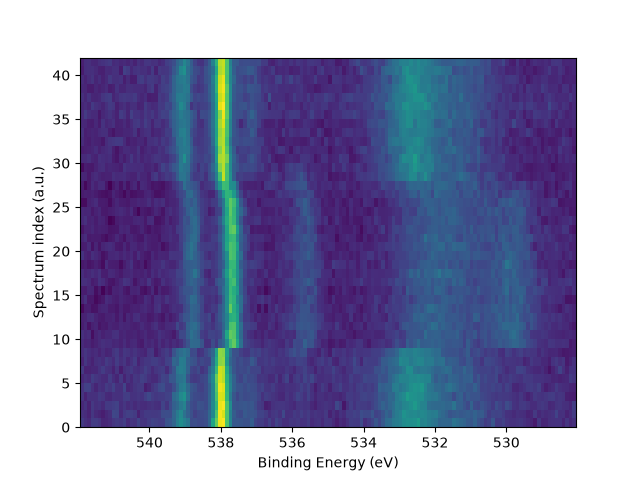

In [2]:
data_path = Path('data/O1s_2.h5')

start = time.time()
loader = XPSDataLoader()

spectra = loader.load(data_path)

xps = spectra[0].get("raw", "xps")
binding_e = spectra[0].get("raw",  "binding_energy")

stop = time.time()

print(f"Data loaded in {stop - start:.2f} seconds and contains the following arrays:")
# print the contained arrays in a Node
for elem in spectra[0].nodes['raw'].arrays:
    print(elem)

plt.close()
fig, ax = plt.subplots()
extent = [binding_e[0], binding_e[-1], 0, len(xps)]
ax.imshow(np.flipud(xps), aspect='auto', extent=extent)
ax.set_xlabel('Binding Energy (eV)')
ax.set_ylabel('Spectrum index (a.u.)')

## Event-mode file: `scienta_peak_h5_events` loader

Loads an **event-mode** `.h5` file, where the instrument records individual detection events (a timestamp + kinetic-energy pair per event) instead of pre-binned spectra. This loader histograms those raw events into a 2D (time × energy) array, so the binning has to be configured explicitly:

- `energy_bin_size` — width of each energy bin, in eV.
- `time_start` / `time_end` — the time window (in seconds) to bin over; must stay within the acquisition's dwell time.
- `time_bin_size` — width of each time bin, in seconds.

Because this isn't the default loader, `loader_name="scienta_peak_h5_events"` is passed explicitly to `loader.load(...)`.

The resulting plot shows binned intensity with binding energy on the x-axis and time (within the acquisition) on the y-axis — useful for watching how a spectrum evolves during a single exposure.

Data loaded in 0.51 seconds and contains the following arrays:
xps
energy_axis
binding_energy
kinetic_energy
time_axis
start_time
stop_time


Text(0, 0.5, 'Time (s)')

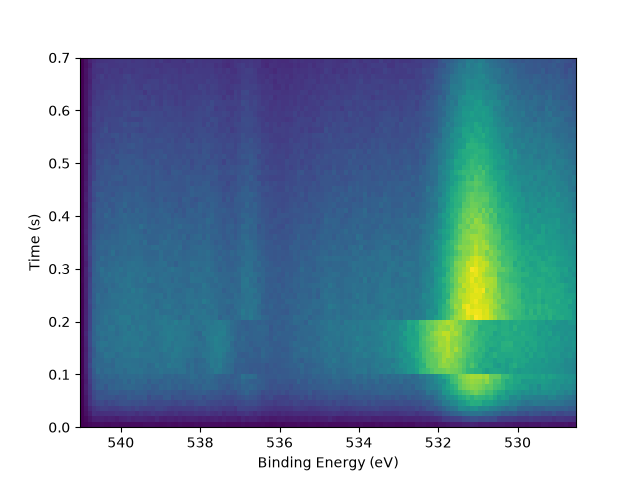

In [3]:
data_path = Path('data/O1s tr 0122.h5')

start = time.time()
loader = XPSDataLoader()

# set binning parameters here
energy_bin_size = 0.1               # energy bin in eV
time_start = 0                      # start of acquisition (usually 0) in seconds
time_end = 0.7                      # end of acquisition in seconds. OBS: should be less than dwell time (1 s for this file)
time_bin_size = 0.01                # size of the time bin in seconds

spectra = loader.load(data_path, energy_bin_size=energy_bin_size, time_bin_size=time_bin_size, time_range=(time_start, time_end), loader_name="scienta_peak_h5_events")

xps = spectra[0].get("raw", "xps")
binding_e = spectra[0].get("raw",  "binding_energy")

stop = time.time()

print(f"Data loaded in {stop - start:.2f} seconds and contains the following arrays:")
# print the contained arrays in a Node
for elem in spectra[0].nodes['raw'].arrays:
    print(elem)

plt.close()
fig, ax = plt.subplots()
extent = [binding_e[0], binding_e[-1], time_start, time_end]
ax.imshow(np.flipud(xps), aspect='auto', extent=extent)
ax.set_xlabel('Binding Energy (eV)')
ax.set_ylabel('Time (s)')

## Snapshot file: `scienta_peak_h5_snapshot` loader

Loads a single-acquisition **snapshot** `.h5` file: unlike a sequence file it has no `shortcuts`/run grouping and holds just one acquisition, but that acquisition still contains repeated energy-scan iterations. Since the file has no per-loop logged timestamps, per-iteration times are synthesized evenly across the acquisition window using the dwell time.

`loader_name` is passed positionally here as `'scienta_peak_h5_snapshot'`; no extra binning parameters are needed since the data is already binned by the instrument.

As with the sequence loader, the plot shows intensity with binding energy on the x-axis and iteration index on the y-axis.

Data loaded in 0.01 seconds and contains the following arrays:
xps
energy_axis
binding_energy
kinetic_energy
iter_axis
acq_time
start_time
stop_time


Text(0, 0.5, 'Spectrum index (a.u.)')

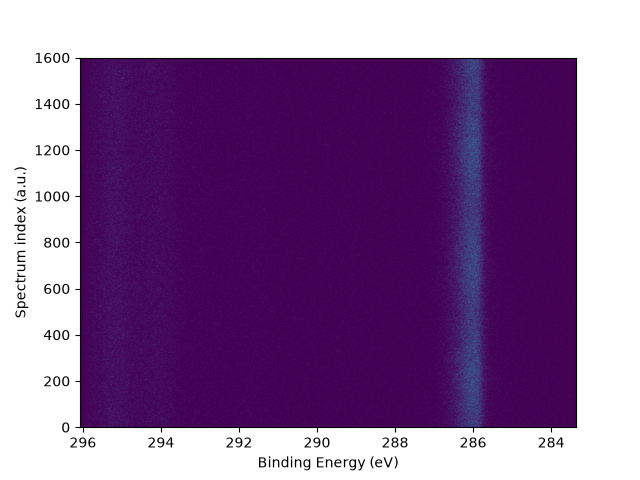

In [4]:
data_path = Path('data/C 1s GP 0017.h5')

start = time.time()
loader = XPSDataLoader()

spectra = loader.load(data_path, 'scienta_peak_h5_snapshot')

xps = spectra[0].get("raw", "xps")
binding_e = spectra[0].get("raw",  "binding_energy")

stop = time.time()

print(f"Data loaded in {stop - start:.2f} seconds and contains the following arrays:")
# print the contained arrays in a Node
for elem in spectra[0].nodes['raw'].arrays:
    print(elem)

plt.close()
fig, ax = plt.subplots()
extent = [binding_e[0], binding_e[-1], 0, len(xps)]
ax.imshow(np.flipud(xps), aspect='auto', extent=extent)
ax.set_xlabel('Binding Energy (eV)')
ax.set_ylabel('Spectrum index (a.u.)')